
# Flexible CSI Time‑Series Fine‑Tuning (Transfer Learning) — Keras/TensorFlow

This notebook plugs into your **latest pretrain CNN** (`CSI_Windows_Supervised.ipynb`) even if the architecture/norm changed.

**Highlights**
- Loads a pretrained model (SavedModel / `.keras` / `.h5`) and **auto-detects an embedding layer** to form a backbone.
- Handles **input channel (C) mismatch** by adapting the first Conv1D weights.
- Optional **AveCSI** (toggle). If disabled, uses **per-window z‑norm** (common in supervised CNNs).
- **Warmup (frozen)** → **unfreeze & fine‑tune**, class weights, CSV metrics, SavedModel export.


In [122]:

#@title Imports
import os, glob, json, math, re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix

tf.keras.utils.set_random_seed(42)
AUTOTUNE = tf.data.AUTOTUNE
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [123]:
#@title Config
TRAIN_ROOT = "/home/tonyliao/WIFI_SENSING_LOCATION/FineTuning_Dataset/training_set"  #@param {type:"string"}
VAL_ROOT   = "/home/tonyliao/WIFI_SENSING_LOCATION/FineTuning_Dataset/val_set"  #@param {type:"string"}
TEST_ROOT  = "/home/tonyliao/WIFI_SENSING_LOCATION/FineTuning_Dataset/test_set"  #@param {type:"string"}

CLASSES = ["Empty", "Stationary"]  #@param {type:"raw"}
CLASS_FOLDERS = None  #@param {type:"raw"}
FORCE_LAYOUT = "TC"  #@param ["TC", "CT"]

FEATURE_MODE = "amp+sin_cos"  #@param ['amp', 'amp+phase', 'amp+sin_cos', 'amp+phase+sin_cos']
VALID_FEATURE_MODES = {"amp", "amp+phase", "amp+sin_cos", "amp+phase+sin_cos"}
if FEATURE_MODE not in VALID_FEATURE_MODES:
    raise ValueError(f"Unsupported FEATURE_MODE={FEATURE_MODE}. Valid: {sorted(VALID_FEATURE_MODES)}")

TARGET_T = 512  #@param {type:"integer"}
BATCH = 128  #@param {type:"integer"}

USE_AVECSI = True  #@param {type:"boolean"}
AVECSI_CACHE_DIR = "checkpoints_ft"  #@param {type:"string"}

# Anchor-distance configuration
ENABLE_ANCHOR_DISTANCE = True  #@param {type:"boolean"}
ANCHOR_LOCATION_NAME = "A"  #@param {type:"string"}
WAVELENGTH_METERS = 0.032  #@param {type:"number"}
DISTANCE_LOSS_WEIGHT = 0.2  #@param {type:"number"}
STANDARDIZE_DISTANCE = True  #@param {type:"boolean"}
ANCHOR_REFERENCE_ROOT = "/home/tonyliao/WIFI_SENSING_LOCATION/PreCNN_Dataset/training_set"  #@param {type:"string"}
ANCHOR_REFERENCE_EMPTY_CLASS = "Empty"  #@param {type:"string"}
ANCHOR_CLASS_FOLDERS = None  #@param {type:"raw"}

EPOCHS = 40  #@param {type:"integer"}
WARMUP_FREEZE = 5  #@param {type:"integer"}
LR_HEAD = 3e-4  #@param {type:"number"}
LR_UNFROZEN = 1e-4  #@param {type:"number"}
WEIGHT_DECAY = 1e-4  #@param {type:"number"}

PRETRAINED_PATH = "/home/tonyliao/WIFI_SENSING_LOCATION/runs_windows_supervised_avecsi/clf_windows_avecsi.h5"  #@param {type:"string"}

OUT_DIR = "finetune_latest"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Feature mode: {FEATURE_MODE}")
print(f"Anchor distance head: {ENABLE_ANCHOR_DISTANCE}")


if ENABLE_ANCHOR_DISTANCE:
    print(f"Anchor reference root: {ANCHOR_REFERENCE_ROOT}")
    print(f"Anchor reference empty class: {ANCHOR_REFERENCE_EMPTY_CLASS}")

In [124]:
#@title Helpers: files, loading, AveCSI, phase-aware extras

def list_window_files(root_dir: str, class_names, class_dir_map=None):
    files, labels = [], []
    if not root_dir or not os.path.isdir(root_dir):
        return files, np.array([], dtype=np.int32)
    for ci, cname in enumerate(class_names):
        subdir = class_dir_map.get(cname, cname) if class_dir_map else cname
        patt = os.path.join(root_dir, subdir, "**", "X_window_*.npy")
        fns = [f for f in glob.glob(patt, recursive=True) if os.path.isfile(f)]
        if len(fns) == 0:
            warn_root = os.path.join(root_dir, subdir)
            print(f"[WARN] no windows for class '{cname}' under {warn_root}")
        files.extend(sorted(fns))
        labels.extend([ci] * len(fns))
    return files, np.array(labels, dtype=np.int32)


def ensure_channels_first(arr, force_layout="TC"):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if force_layout == "TC":
        return arr.T
    if force_layout == "CT":
        return arr
    raise ValueError(f"Unknown force_layout '{force_layout}'")

def related_window_path(path, stem):
    base_dir, fname = os.path.split(path)
    if not fname.startswith("X_window_"):
        raise ValueError(f"Unexpected window filename: {fname}")
    suffix = fname[len("X_window_"):]
    return os.path.join(base_dir, f"{stem}{suffix}")

def wants_raw_phase(mode: str) -> bool:
    return "phase" in mode and mode != "amp+sin_cos"

def wants_sin_cos(mode: str) -> bool:
    return "sin_cos" in mode

def expected_feature_names(mode: str):
    names = []
    if wants_raw_phase(mode):
        names.append("phase")
    if wants_sin_cos(mode):
        names.extend(["phase_sin", "phase_cos"])
    return names

def load_window_components(path, feature_mode="amp", force_layout="TC"):
    amp = ensure_channels_first(np.load(path), force_layout=force_layout)
    extras, names = [], []
    missing = set()
    if feature_mode != "amp":
        if wants_raw_phase(feature_mode):
            phase_path = related_window_path(path, "Xphase_window_")
            if os.path.isfile(phase_path):
                phase = ensure_channels_first(np.load(phase_path), force_layout=force_layout)
                extras.append(phase)
                names.append("phase")
            else:
                missing.add("phase")
                extras.append(np.zeros_like(amp, dtype=np.float32))
                names.append("phase")
        if wants_sin_cos(feature_mode):
            sc_path = related_window_path(path, "XphaseSC_window_")
            if os.path.isfile(sc_path):
                sc = np.load(sc_path)
                if sc.ndim != 3 or sc.shape[-1] != 2:
                    raise ValueError(f"{sc_path} expected shape [T, S, 2], got {sc.shape}")
                sin_comp = ensure_channels_first(sc[:, :, 0], force_layout=force_layout)
                cos_comp = ensure_channels_first(sc[:, :, 1], force_layout=force_layout)
                extras.extend([sin_comp, cos_comp])
                names.extend(["phase_sin", "phase_cos"])
            else:
                missing.update({"phase_sin", "phase_cos"})
                extras.extend([np.zeros_like(amp, dtype=np.float32), np.zeros_like(amp, dtype=np.float32)])
                names.extend(["phase_sin", "phase_cos"])
    amp = amp.astype(np.float32)
    extras = [np.asarray(e, dtype=np.float32) for e in extras]
    return amp, extras, names, missing

def center_crop(arr, length):
    if length is None or arr.shape[1] <= length:
        return arr
    start = max(0, (arr.shape[1] - length) // 2)
    return arr[:, start:start + length]

def pad_to_length(arr, length):
    if length is None or arr.shape[1] >= length:
        return arr[:, :length] if length is not None else arr
    out = np.zeros((arr.shape[0], length), dtype=arr.dtype)
    out[:, :arr.shape[1]] = arr
    return out

def compute_shape_stats(paths, force_layout="TC", crop_len=None):
    C_first, T_list = None, []
    for p in paths[:4096]:
        try:
            X = np.load(p)
        except Exception:
            continue
        if X.ndim != 2:
            continue
        if force_layout == "TC":
            C, T = (X.shape[1], X.shape[0]) if X.shape[0] > X.shape[1] else (X.shape[0], X.shape[1])
        else:
            C, T = X.shape if X.shape[0] >= X.shape[1] else (X.shape[1], X.shape[0])
        if C_first is None:
            C_first = C
        T_list.append(T if crop_len is None else crop_len)
    return C_first, (min(T_list) if T_list else None), (max(T_list) if T_list else None)

def summarize_feature_presence(paths, feature_mode="amp", force_layout="TC"):
    component_order = None
    missing_counter = Counter()
    for p in paths:
        amp, extras, names, missing = load_window_components(p, feature_mode, force_layout)
        if component_order is None:
            component_order = ["amp"] + names
        missing_counter.update(missing)
    if component_order is None:
        component_order = ["amp"]
    return component_order, {k: int(v) for k, v in missing_counter.items()}

def compute_extra_feature_stats(paths, feature_mode="amp", force_layout="TC", crop_len=None):
    if feature_mode == "amp":
        return {}
    has_any = wants_raw_phase(feature_mode) or wants_sin_cos(feature_mode)
    if not has_any:
        return {}
    sums, sums_sq, counts = {}, {}, {}
    for p in paths:
        _, extras, names, missing = load_window_components(p, feature_mode, force_layout)
        for name, arr in zip(names, extras):
            if name in missing:
                continue
            arr = arr.astype(np.float32)
            if crop_len is not None:
                arr = center_crop(arr, crop_len)
                arr = pad_to_length(arr, crop_len)
            sums.setdefault(name, np.zeros((arr.shape[0], 1), dtype=np.float64))
            sums_sq.setdefault(name, np.zeros((arr.shape[0], 1), dtype=np.float64))
            counts.setdefault(name, 0)
            sums[name] += arr.sum(axis=1, keepdims=True)
            sums_sq[name] += (arr ** 2).sum(axis=1, keepdims=True)
            counts[name] += arr.shape[1]
    stats = {}
    for name, total in sums.items():
        if counts.get(name, 0) == 0:
            continue
        mu = (total / counts[name]).astype(np.float32)
        var = (sums_sq[name] / counts[name]) - (mu.astype(np.float64) ** 2)
        var = np.maximum(var, 1e-12)
        sigma = (np.sqrt(var).astype(np.float32) + 1e-6)
        stats[name] = (mu, sigma)
    return stats

def load_np_window(path, force_layout="TC"):
    return ensure_channels_first(np.load(path), force_layout=force_layout)


def load_or_compute_avecsi(cache_dir, train_root, force_layout="TC", class_names=("Empty", "Stationary"), class_dir_map=None):
    Path(cache_dir).mkdir(parents=True, exist_ok=True)
    ave_path = os.path.join(cache_dir, "avecsi_stats_latest.npz")
    paths0, _ = list_window_files(train_root, [class_names[0]], class_dir_map=class_dir_map)
    if len(paths0) == 0:
        raise RuntimeError("No windows found to compute AveCSI (looked for class[0]).")
    X0 = load_np_window(paths0[0], force_layout=force_layout)
    C_expected = X0.shape[0]
    if os.path.isfile(ave_path):
        z = np.load(ave_path)
        if z["mu"].shape[0] == C_expected:
            print(f"[AveCSI] Loaded {ave_path} (C={C_expected})")
            return z["mu"].astype(np.float32), z["sigma"].astype(np.float32)
    all_paths, _ = list_window_files(train_root, class_names, class_dir_map=class_dir_map)
    use = all_paths if len(all_paths) <= 4096 else all_paths[:4096]
    acc = [load_np_window(p, force_layout=force_layout) for p in use]
    A = np.concatenate(acc, axis=1)  # (C, sumT)
    mu = A.mean(axis=1).astype(np.float32)
    sigma = (A.std(axis=1) + 1e-6).astype(np.float32)
    np.savez_compressed(ave_path, mu=mu, sigma=sigma)
    print(f"[AveCSI] Computed -> {ave_path}")
    return mu, sigma


def compute_anchor_phase_profile(empty_paths, force_layout="TC", crop_len=None):
    accum = []
    for p in empty_paths:
        phase_path = related_window_path(p, "Xphase_window_")
        if not os.path.isfile(phase_path):
            continue
        phase = ensure_channels_first(np.load(phase_path), force_layout=force_layout).astype(np.float32)
        if crop_len is not None:
            phase = center_crop(phase, crop_len)
        unwrapped = np.unwrap(phase, axis=1)
        accum.append(unwrapped.mean(axis=1))
    if not accum:
        raise RuntimeError("Unable to compute anchor phase profile; no valid phase windows located for the empty class.")
    anchor = np.mean(accum, axis=0).astype(np.float32)
    return anchor


def estimate_anchor_distance(phase_window, anchor_profile, wavelength):
    if phase_window is None or anchor_profile is None or wavelength is None:
        return np.nan
    unwrapped = np.unwrap(phase_window, axis=1)
    mean_phase = unwrapped.mean(axis=1)
    if anchor_profile.shape[0] != mean_phase.shape[0]:
        raise ValueError(
            f"Anchor profile channel count {anchor_profile.shape[0]} != phase window channels {mean_phase.shape[0]}"
        )
    delta = mean_phase - anchor_profile
    distance = float(np.mean(delta) * (wavelength / (2.0 * np.pi)))
    return distance



def estimate_anchor_distances(paths, anchor_profile, feature_mode="amp", force_layout="TC", crop_len=None, wavelength=None):
    paths = list(paths)
    if anchor_profile is None or not wants_raw_phase(feature_mode):
        if anchor_profile is None:
            print("[Anchor] No anchor profile available; skipping distance estimation.")
        else:
            print("[Anchor] FEATURE_MODE lacks raw phase; distance head disabled.")
        info = {"missing_phase": len(paths), "total": len(paths), "errors": 0}
        return np.full(len(paths), np.nan, dtype=np.float32), info
    if wavelength is None:
        wavelength = globals().get("WAVELENGTH_METERS")
    distances = []
    missing = 0
    errors = 0
    for p in paths:
        phase_path = related_window_path(p, "Xphase_window_")
        if not os.path.isfile(phase_path):
            distances.append(np.nan)
            missing += 1
            continue
        phase = ensure_channels_first(np.load(phase_path), force_layout=force_layout).astype(np.float32)
        if crop_len is not None:
            phase = center_crop(phase, crop_len)
            phase = pad_to_length(phase, crop_len)
        try:
            d = estimate_anchor_distance(phase, anchor_profile, wavelength) if wavelength is not None else np.nan
        except Exception as e:
            print(f"[WARN] Distance estimation failed for {os.path.basename(p)}: {e}")
            d = np.nan
            errors += 1
        distances.append(d)
    info = {"missing_phase": int(missing), "total": len(paths), "errors": int(errors)}
    return np.array(distances, dtype=np.float32), info


def compute_distance_scaler(distances):
    arr = np.asarray(distances, dtype=np.float32)
    if arr.size == 0:
        return {"mean": 0.0, "std": 1.0}
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return {"mean": 0.0, "std": 1.0}
    return {"mean": float(finite.mean()), "std": float(finite.std() + 1e-6)}


def load_np_window(path, force_layout="TC"):
    return ensure_channels_first(np.load(path), force_layout=force_layout)

def compute_anchor_phase_profile(empty_paths, force_layout="TC", crop_len=None):
    accum = []
    for p in empty_paths:
        phase_path = related_window_path(p, "Xphase_window_")
        if not os.path.isfile(phase_path):
            continue
        phase = ensure_channels_first(np.load(phase_path), force_layout=force_layout).astype(np.float32)
        if crop_len is not None:
            phase = center_crop(phase, crop_len)
        unwrapped = np.unwrap(phase, axis=1)
        accum.append(unwrapped.mean(axis=1))
    if not accum:
        raise RuntimeError("Unable to compute anchor phase profile; no valid phase windows located for the empty class.")
    anchor = np.mean(accum, axis=0).astype(np.float32)
    return anchor


def estimate_anchor_distance(phase_window, anchor_profile, wavelength):
    if phase_window is None or anchor_profile is None or wavelength is None:
        return np.nan
    unwrapped = np.unwrap(phase_window, axis=1)
    mean_phase = unwrapped.mean(axis=1)
    if anchor_profile.shape[0] != mean_phase.shape[0]:
        raise ValueError(
            f"Anchor profile channel count {anchor_profile.shape[0]} != phase window channels {mean_phase.shape[0]}"
        )
    delta = mean_phase - anchor_profile
    distance = float(np.mean(delta) * (wavelength / (2.0 * np.pi)))
    return distance


def compute_distance_targets(paths, feature_mode="amp", force_layout="TC", target_T=None,
                             anchor_profile=None, wavelength=None):
    paths = list(paths)
    if anchor_profile is None or wavelength is None or not wants_raw_phase(feature_mode):
        if anchor_profile is None:
            print("[Anchor] No anchor profile available; skipping distance targets.")
        elif not wants_raw_phase(feature_mode):
            print("[Anchor] FEATURE_MODE lacks raw phase; distance targets disabled.")
        return np.full(len(paths), np.nan, dtype=np.float32), {"missing_phase": len(paths), "total": len(paths)}

    distances = []
    missing = 0
    for p in paths:
        phase_path = related_window_path(p, "Xphase_window_")
        if not os.path.isfile(phase_path):
            distances.append(np.nan)
            missing += 1
            continue
        phase = ensure_channels_first(np.load(phase_path), force_layout=force_layout).astype(np.float32)
        if target_T is not None:
            phase = center_crop(phase, target_T)
            phase = pad_to_length(phase, target_T)
        try:
            d = estimate_anchor_distance(phase, anchor_profile, wavelength)
        except Exception as e:
            print(f"[WARN] Distance estimation failed for {os.path.basename(p)}: {e}")
            d = np.nan
        distances.append(d)
    return np.array(distances, dtype=np.float32), {"missing_phase": int(missing), "total": len(paths)}



In [125]:

# --- Alias-aware loader: merge multiple folder names per class ---
def list_window_files_with_aliases(root_dir: str, class_aliases):
    import glob, os, numpy as np
    files, labels = [], []
    for ci, alias in enumerate(class_aliases):
        names = alias if isinstance(alias, (list, tuple)) else [alias]
        found = 0
        for cname in names:
            patt = os.path.join(root_dir, cname, "**", "X_window*.npy")
            fns = [f for f in glob.glob(patt, recursive=True) if os.path.isfile(f)]
            files.extend(sorted(fns))
            labels.extend([ci]*len(fns))
            found += len(fns)
        if found == 0:
            print(f"[WARN] no windows for aliases {names} under {root_dir}")
    return files, np.array(labels, dtype=np.int32)


In [126]:
#@title tf.data pipeline
def make_ds(paths, labels, target_T, batch, shuffle=False, repeat=False, force_layout="TC",
            use_avecsi=False, mu=None, sigma=None, feature_mode="amp", extra_stats=None,
            distance_targets=None, class_weight_map=None):
    if len(paths) == 0:
        raise ValueError("No window paths provided to make_ds.")
    extra_stats = extra_stats or {}
    component_order, missing_counts = summarize_feature_presence(paths, feature_mode, force_layout)
    amp0, _, _, _ = load_window_components(paths[0], feature_mode, force_layout)
    base_channels = amp0.shape[0]
    total_components = len(component_order)
    total_channels = base_channels * total_components
    missing_stats = [name for name in component_order[1:] if name not in extra_stats]

    if use_avecsi and mu is not None and sigma is not None:
        mu = mu.astype(np.float32)
        sigma = sigma.astype(np.float32)

    distance_targets = None if distance_targets is None else np.asarray(distance_targets, dtype=np.float32)
    if distance_targets is not None and distance_targets.shape[0] != len(paths):
        raise ValueError("distance_targets must align with paths.")

    if class_weight_map is not None:
        class_weight_map = {int(k): float(v) for k, v in class_weight_map.items()}
    include_weights = class_weight_map is not None

    def _load_py_base(path):
        if isinstance(path, (bytes, bytearray)):
            return path.decode('utf-8')
        try:
            return path.numpy().decode('utf-8')
        except Exception:
            return str(path)

    def _build_features(path):
        amp, extras, names, missing = load_window_components(path, feature_mode, force_layout)
        amp = amp.astype(np.float32)
        if use_avecsi and mu is not None and sigma is not None:
            amp = (amp - mu[:, None]) / (sigma[:, None] + 1e-6)
        else:
            m = amp.mean(axis=1, keepdims=True)
            s = amp.std(axis=1, keepdims=True) + 1e-6
            amp = (amp - m) / s
        parts = [amp]
        for name, arr in zip(names, extras):
            arr = arr.astype(np.float32)
            if name in missing:
                arr = np.zeros_like(arr)
            elif name in extra_stats:
                mu_e, sigma_e = extra_stats[name]
                arr = (arr - mu_e) / (sigma_e + 1e-6)
            else:
                m = arr.mean(axis=1, keepdims=True)
                s = arr.std(axis=1, keepdims=True) + 1e-6
                arr = (arr - m) / s
            parts.append(arr)
        if len(parts) > total_components:
            parts = parts[:total_components]
        stacked = np.concatenate(parts, axis=0)
        stacked = center_crop(stacked, target_T)
        stacked = pad_to_length(stacked, target_T)
        return stacked.astype(np.float32)

    if distance_targets is None:
        if include_weights:
            def _load_py(p, y):
                path = _load_py_base(p)
                X = _build_features(path)
                yy = np.int32(y)
                ww = np.float32(class_weight_map.get(int(yy), 1.0))
                return X, yy, ww

            def _tf_map(p, y):
                X, yy, ww = tf.numpy_function(_load_py, [p, y], [tf.float32, tf.int32, tf.float32])
                X.set_shape([total_channels, target_T])
                yy.set_shape([])
                ww.set_shape([])
                return X, yy, ww
        else:
            def _load_py(p, y):
                path = _load_py_base(p)
                X = _build_features(path)
                return X, np.int32(y)

            def _tf_map(p, y):
                X, yy = tf.numpy_function(_load_py, [p, y], [tf.float32, tf.int32])
                X.set_shape([total_channels, target_T])
                yy.set_shape([])
                return X, yy

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    else:
        if include_weights:
            def _load_py(p, y, d):
                path = _load_py_base(p)
                X = _build_features(path)
                yy = np.int32(y)
                dd = np.float32(d)
                ww = np.float32(class_weight_map.get(int(yy), 1.0))
                return X, yy, dd, ww

            def _tf_map(p, y, d):
                X, yy, dd, ww = tf.numpy_function(_load_py, [p, y, d], [tf.float32, tf.int32, tf.float32, tf.float32])
                X.set_shape([total_channels, target_T])
                yy.set_shape([])
                dd.set_shape([])
                ww.set_shape([])
                sample_weights = {"cls": ww, "distance": tf.ones_like(dd)}
                return X, {"cls": yy, "distance": dd}, sample_weights
        else:
            def _load_py(p, y, d):
                path = _load_py_base(p)
                X = _build_features(path)
                return X, np.int32(y), np.float32(d)

            def _tf_map(p, y, d):
                X, yy, dd = tf.numpy_function(_load_py, [p, y, d], [tf.float32, tf.int32, tf.float32])
                X.set_shape([total_channels, target_T])
                yy.set_shape([])
                dd.set_shape([])
                return X, {"cls": yy, "distance": dd}

        ds = tf.data.Dataset.from_tensor_slices((paths, labels, distance_targets))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 10000), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(_tf_map, num_parallel_calls=AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    info = {
        'channels': int(total_channels),
        'base_channels': int(base_channels),
        'components': component_order,
        'missing_features': missing_counts,
        'missing_stats': missing_stats,
        'total_windows': int(len(paths)),
        'distance_targets': distance_targets is not None,
        'class_weight_map': class_weight_map,
        'sample_weights': include_weights,
    }
    return ds, info


In [127]:

#@title Pretrained → backbone (auto embedding) + channel adaptation
def find_embedding_layer(model):
    gap_name = None; dense_before = None
    for l in model.layers[::-1]:
        if isinstance(l, layers.GlobalAveragePooling1D):
            gap_name = l.name; break
        if isinstance(l, layers.Dense) and l.units >= 32 and not re.search("(logit|pred|output)$", l.name, re.I):
            if dense_before is None: dense_before = l.name
    return gap_name or dense_before

def wrap_backbone_from_model(loaded, embed_name):
    inp = loaded.input
    h = loaded.get_layer(embed_name).output
    return models.Model(inp, h, name="backbone_from_pretrain")

def adapt_first_conv1d_channels(backbone, C_target):
    try:
        if backbone.input_shape[-2] == C_target:
            return backbone
        conf = backbone.to_json()
        new_b = keras.models.model_from_json(conf)
        # transfer weights layer-wise, we will correct first Conv1D next
        for l in new_b.layers:
            try:
                lw = backbone.get_layer(l.name).get_weights()
                l.set_weights(lw)
            except Exception:
                pass
        for l in new_b.layers:
            if isinstance(l, layers.Conv1D):
                try:
                    W, b = l.get_weights()  # (k, Cin, Cout)
                    if W.shape[1] != C_target:
                        Wm = W.mean(axis=1, keepdims=True)
                        W_new = np.repeat(Wm, C_target, axis=1)
                        l.set_weights([W_new, b])
                    break
                except Exception:
                    continue
        return new_b
    except Exception as e:
        print("[WARN] Channel-adaptation skipped:", e)
        return backbone

def load_pretrained_as_backbone(path, C_target):
    if not path or not os.path.exists(path):
        return None
    print(f"[Pretrained] Loading: {path}")
    try:
        mdl = keras.models.load_model(path, compile=False)
        emb = find_embedding_layer(mdl) or mdl.layers[-2].name
        bb = wrap_backbone_from_model(mdl, emb)
        if bb.input_shape[-2] != C_target:
            print(f"[Pretrained] Adapting Conv1D Cin {bb.input_shape[-2]} -> {C_target}")
            bb = adapt_first_conv1d_channels(bb, C_target)
        return bb
    except Exception as e:
        print("[Pretrained] Load failed:", e)
        return None


In [128]:
def build_backbone_1d(in_channels: int, T: int, hidden: int = 128, wd: float = 1e-4, name="csi_backbone"):
    inp = layers.Input(shape=(in_channels, T), name="csi_in")
    x = layers.Permute((2,1), name="permute_T_C")(inp)
    x = layers.Conv1D(hidden, 7, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(wd), name="conv1")(x)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.MaxPooling1D(2, name="pool1")(x)
    x = layers.Conv1D(hidden, 5, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(wd), name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.MaxPooling1D(2, name="pool2")(x)
    x = layers.Dropout(0.2, name="drop2")(x)
    x = layers.Conv1D(hidden*2, 1, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(wd), name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    h = layers.GlobalAveragePooling1D(name="gap")(x)
    h = layers.Dense(hidden, activation="relu", name="embed")(h)
    return models.Model(inp, h, name=name)

def load_encoder_weights_into_fresh_backbone(encoder_h5_path, C_target, T_target, wd=1e-4, hidden=128):
    # 1) Load your pretrained encoder (old input, e.g., 114x2400)
    enc = keras.models.load_model(encoder_h5_path, compile=False)

    # 2) Build a *fresh* backbone with (C_target, T_target)
    fresh = build_backbone_1d(C_target, T_target, hidden=hidden, wd=wd)

    # 3) Copy weights layer-by-layer; adapt first Conv1D input channels if needed
    def safe_set(dst, src):
        try:
            dst.set_weights(src.get_weights())
            return True
        except Exception:
            return False

    # Names we expect to exist in both
    names = ["conv1","bn1","conv2","bn2","conv3","bn3","embed"]
    for nm in names:
        try:
            L_src = enc.get_layer(nm)
            L_dst = fresh.get_layer(nm)
            if isinstance(L_dst, layers.Conv1D) and isinstance(L_src, layers.Conv1D):
                W_src, b_src = L_src.get_weights()  # (k, Cin_src, Cout)
                W_dst, b_dst = L_dst.get_weights()  # (k, Cin_dst, Cout)
                if W_src.shape[1] != W_dst.shape[1]:
                    # Channel adapt: average across input channels then tile to Cin_dst
                    Wm = W_src.mean(axis=1, keepdims=True)
                    W_new = np.repeat(Wm, W_dst.shape[1], axis=1)
                    L_dst.set_weights([W_new, b_src])
                else:
                    L_dst.set_weights([W_src, b_src])
            else:
                # BN, Dense (embed), etc. — copy if shapes match
                ok = safe_set(L_dst, L_src)
                if not ok:
                    # If embed width differs, skip; the new head will retrain it anyway
                    pass
        except Exception:
            # Missing layer name or incompatible — skip
            pass

    return fresh

def attach_head(backbone, num_classes: int, include_distance_head: bool = False):
    features = backbone.outputs[0]
    cls_logits = layers.Dense(num_classes, activation=None, name="cls_logits")(features)
    if include_distance_head:
        distance_out = layers.Dense(1, activation=None, name="distance")(features)
        outputs = {"cls": cls_logits, "distance": distance_out}
        model_name = "clf_loc_windows"
    else:
        outputs = cls_logits
        model_name = "clf_windows_avecsi"
    return models.Model(backbone.inputs[0], outputs, name=model_name)

def load_encoder_weights_into_fresh_backbone(encoder_h5_path, C_target, T_target, wd=1e-4, hidden=128):
    # 1) Load your pretrained encoder (old input, e.g., 114x2400)
    enc = keras.models.load_model(encoder_h5_path, compile=False)

    # 2) Build a *fresh* backbone with (C_target, T_target)
    fresh = build_backbone_1d(C_target, T_target, hidden=hidden, wd=wd)

    # 3) Copy weights layer-by-layer; adapt first Conv1D input channels if needed
    def safe_set(dst, src):
        try:
            dst.set_weights(src.get_weights())
            return True
        except Exception:
            return False

    # Names we expect to exist in both
    names = ["conv1","bn1","conv2","bn2","conv3","bn3","embed"]
    for nm in names:
        try:
            L_src = enc.get_layer(nm)
            L_dst = fresh.get_layer(nm)
            if isinstance(L_dst, layers.Conv1D) and isinstance(L_src, layers.Conv1D):
                W_src, b_src = L_src.get_weights()  # (k, Cin_src, Cout)
                W_dst, b_dst = L_dst.get_weights()  # (k, Cin_dst, Cout)
                if W_src.shape[1] != W_dst.shape[1]:
                    # Channel adapt: average across input channels then tile to Cin_dst
                    Wm = W_src.mean(axis=1, keepdims=True)
                    W_new = np.repeat(Wm, W_dst.shape[1], axis=1)
                    L_dst.set_weights([W_new, b_src])
                else:
                    L_dst.set_weights([W_src, b_src])
            else:
                # BN, Dense (embed), etc. — copy if shapes match
                ok = safe_set(L_dst, L_src)
                if not ok:
                    # If embed width differs, skip; the new head will retrain it anyway
                    pass
        except Exception:
            # Missing layer name or incompatible — skip
            pass

    return fresh



In [129]:

# === Stratified downsample to 1/4 per class and rebuild datasets ===
import numpy as np
from collections import defaultdict, Counter

FRAC = 0.25          # pick your fraction
SEED = 42            # for reproducibility

rng = np.random.default_rng(SEED)

def stratified_subset(paths, labels, frac=0.25, min_per_class=1):
    paths = np.array(paths)
    labels = np.array(labels)
    idx_by_cls = defaultdict(list)
    for i, y in enumerate(labels):
        idx_by_cls[int(y)].append(i)
    keep_idx = []
    for y, idxs in idx_by_cls.items():
        idxs = np.array(idxs)
        n = max(min_per_class, int(np.floor(len(idxs) * frac)))
        sel = rng.choice(idxs, size=n, replace=False)
        keep_idx.extend(sel.tolist())
    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)
    return paths[keep_idx].tolist(), labels[keep_idx]

tr_paths, tr_labels = list_window_files(TRAIN_ROOT, CLASSES, class_dir_map=CLASS_FOLDERS)
va_paths, va_labels = list_window_files(VAL_ROOT, CLASSES, class_dir_map=CLASS_FOLDERS)
te_paths, te_labels = ([], None)
if TEST_ROOT:
    te_paths, te_labels = list_window_files(TEST_ROOT, CLASSES, class_dir_map=CLASS_FOLDERS)

mu = sigma = None
if USE_AVECSI:
    mu, sigma = load_or_compute_avecsi(AVECSI_CACHE_DIR, TRAIN_ROOT, force_layout=FORCE_LAYOUT,
                                      class_names=CLASSES, class_dir_map=CLASS_FOLDERS)

extra_stats = {}
missing_phase_stats = []
if FEATURE_MODE != "amp":
    extra_stats = compute_extra_feature_stats(tr_paths, feature_mode=FEATURE_MODE,
                                             force_layout=FORCE_LAYOUT, crop_len=TARGET_T)
    expected = expected_feature_names(FEATURE_MODE)
    if extra_stats:
        print("[Phase] Computed stats for:", ", ".join(sorted(extra_stats.keys())))
    missing_phase_stats = [name for name in expected if name not in extra_stats]
    if missing_phase_stats:
        print(f"[WARN] Missing feature stats for {missing_phase_stats}; per-window normalization/zero-fill will be used.")

tr_paths_sub, tr_labels_sub = stratified_subset(tr_paths, tr_labels, FRAC)
va_paths_sub, va_labels_sub = stratified_subset(va_paths, va_labels, FRAC)
te_paths_sub, te_labels_sub = stratified_subset(te_paths, te_labels, FRAC) if te_paths else ([], None)

anchor_phase_profile = None
anchor_source_desc = None
DISTANCE_HEAD_ENABLED = True
DISTANCE_SCALER = None
DISTANCE_TARGETS = {"train": None, "val": None, "test": None}
DISTANCE_RAW = {"train": None, "val": None, "test": None}
DISTANCE_INFO = {}

if ENABLE_ANCHOR_DISTANCE:
    if wants_raw_phase(FEATURE_MODE):
        anchor_empty_class = ANCHOR_REFERENCE_EMPTY_CLASS or (CLASSES[0] if CLASSES else "Empty")
        try:
            anchor_empty_index = int(CLASSES.index(anchor_empty_class))
        except ValueError:
            anchor_empty_index = 0
            if CLASSES:
                print(f"[WARN] Anchor reference class '{ANCHOR_REFERENCE_EMPTY_CLASS}' not present in CLASSES; defaulting to '{CLASSES[0]}'.")
                anchor_empty_class = CLASSES[0]
            else:
                anchor_empty_class = "Empty"
        anchor_candidates = []
        if ANCHOR_REFERENCE_ROOT:
            if os.path.isdir(ANCHOR_REFERENCE_ROOT):
                anchor_dir_map = ANCHOR_CLASS_FOLDERS or CLASS_FOLDERS
                try:
                    anchor_candidates, _ = list_window_files(ANCHOR_REFERENCE_ROOT, [anchor_empty_class], class_dir_map=anchor_dir_map)
                except Exception as e:
                    print(f"[WARN] Unable to gather anchor windows from reference root '{ANCHOR_REFERENCE_ROOT}': {e}")
                    anchor_candidates = []
                if anchor_candidates:
                    anchor_source_desc = f"{ANCHOR_REFERENCE_ROOT} ({anchor_empty_class})"
                    print(f"[Anchor] Loaded {len(anchor_candidates)} reference windows for '{anchor_empty_class}' from {ANCHOR_REFERENCE_ROOT} to profile anchor '{ANCHOR_LOCATION_NAME}'.")
                else:
                    print(f"[WARN] No '{anchor_empty_class}' windows found under anchor reference root {ANCHOR_REFERENCE_ROOT}.")
            else:
                print(f"[WARN] Anchor reference root not found: {ANCHOR_REFERENCE_ROOT}")
        if not anchor_candidates:
            anchor_candidates = [p for p, y in zip(tr_paths, tr_labels) if int(y) == anchor_empty_index]
            if anchor_candidates:
                anchor_source_desc = f"fine-tuning train ({anchor_empty_class})"
                print(f"[Anchor] Falling back to {anchor_source_desc}; found {len(anchor_candidates)} candidate windows for anchor '{ANCHOR_LOCATION_NAME}'.")
            else:
                print("[WARN] Unable to locate any candidate windows for anchor profile computation.")
        if anchor_candidates:
            try:
                anchor_phase_profile = compute_anchor_phase_profile(anchor_candidates, force_layout=FORCE_LAYOUT,
                                                                    crop_len=TARGET_T)
                print(f"[Anchor] Phase profile for '{ANCHOR_LOCATION_NAME}' computed from {anchor_source_desc}.")
            except Exception as e:
                print(f"[WARN] Unable to compute anchor phase profile: {e}")
                anchor_phase_profile = None
                anchor_source_desc = None
        else:
            anchor_phase_profile = None
            anchor_source_desc = None
    else:
        print("[WARN] Anchor distance requested but feature mode lacks raw phase; disabling distance head.")
        DISTANCE_HEAD_ENABLED = False

    if anchor_phase_profile is not None:
        train_dist_raw, DISTANCE_INFO = estimate_anchor_distances(tr_paths_sub, anchor_phase_profile,
                                                                  feature_mode=FEATURE_MODE,
                                                                  force_layout=FORCE_LAYOUT, crop_len=TARGET_T,
                                                                  wavelength=WAVELENGTH_METERS)
        val_dist_raw, _ = estimate_anchor_distances(va_paths_sub, anchor_phase_profile,
                                                    feature_mode=FEATURE_MODE,
                                                    force_layout=FORCE_LAYOUT, crop_len=TARGET_T,
                                                    wavelength=WAVELENGTH_METERS)
        test_dist_raw = None
        if te_paths_sub:
            test_dist_raw, _ = estimate_anchor_distances(te_paths_sub, anchor_phase_profile,
                                                         feature_mode=FEATURE_MODE,
                                                         force_layout=FORCE_LAYOUT, crop_len=TARGET_T,
                                                         wavelength=WAVELENGTH_METERS)

        DISTANCE_RAW = {"train": train_dist_raw, "val": val_dist_raw, "test": test_dist_raw}

        DISTANCE_SCALER = compute_distance_scaler(train_dist_raw)
        def _standardize(arr):
            if arr is None:
                return None
            arr = np.asarray(arr, dtype=np.float32)
            arr = (arr - DISTANCE_SCALER["mean"]) / (DISTANCE_SCALER["std"] + 1e-6)
            return np.nan_to_num(arr, nan=0.0)

        DISTANCE_TARGETS["train"] = _standardize(train_dist_raw)
        DISTANCE_TARGETS["val"] = _standardize(val_dist_raw)
        if te_paths_sub:
            DISTANCE_TARGETS["test"] = _standardize(test_dist_raw)
        DISTANCE_HEAD_ENABLED = True
else:
    DISTANCE_HEAD_ENABLED = False

if not DISTANCE_HEAD_ENABLED:
    DISTANCE_SCALER = None if DISTANCE_SCALER is None else DISTANCE_SCALER
    DISTANCE_TARGETS = {k: None for k in DISTANCE_TARGETS}


def count_by_class(paths, labels, classes):
    c = Counter(labels.tolist())
    for i, name in enumerate(classes):
        print(f"{name:>20s}: {c.get(i,0)}")
    print("Total:", len(paths))

print("[TRAIN 1/4] files per class:"); count_by_class(tr_paths_sub, tr_labels_sub, CLASSES)
print("[VAL   1/4] files per class:"); count_by_class(va_paths_sub, va_labels_sub, CLASSES)
if te_paths_sub:
    print("[TEST  1/4] files per class:"); count_by_class(te_paths_sub, te_labels_sub, CLASSES)

class_counts = np.bincount(tr_labels_sub, minlength=len(CLASSES))
inv = class_counts.mean() / np.maximum(1, class_counts)
CLASS_WEIGHTS = {i: float(inv[i]) for i in range(len(CLASSES))}
print("Class weights (subset):", CLASS_WEIGHTS)

train_distance_targets = DISTANCE_TARGETS["train"] if DISTANCE_HEAD_ENABLED and DISTANCE_TARGETS.get("train") is not None else None
val_distance_targets = DISTANCE_TARGETS["val"] if DISTANCE_HEAD_ENABLED and DISTANCE_TARGETS.get("val") is not None else None
test_distance_targets = None
if DISTANCE_HEAD_ENABLED and te_paths_sub:
    candidate = DISTANCE_TARGETS.get("test")
    if candidate is not None:
        test_distance_targets = candidate
distance_targets_missing = False
if DISTANCE_HEAD_ENABLED and train_distance_targets is None:
    distance_targets_missing = True
    reason = "train"
elif DISTANCE_HEAD_ENABLED and len(va_paths_sub) and val_distance_targets is None:
    distance_targets_missing = True
    reason = "val"
if distance_targets_missing:
    print(f"[WARN] Distance head enabled but missing {reason} distances; disabling distance head.")
    DISTANCE_HEAD_ENABLED = False
    DISTANCE_SCALER = None
    DISTANCE_TARGETS = {k: None for k in DISTANCE_TARGETS}
    train_distance_targets = None
    val_distance_targets = None
    test_distance_targets = None

train_class_weight_map = CLASS_WEIGHTS if DISTANCE_HEAD_ENABLED else None

ds_tr, info_tr = make_ds(tr_paths_sub, tr_labels_sub, TARGET_T, BATCH, shuffle=True,
                        force_layout=FORCE_LAYOUT, use_avecsi=USE_AVECSI, mu=mu if USE_AVECSI else None,
                        sigma=sigma if USE_AVECSI else None, feature_mode=FEATURE_MODE, extra_stats=extra_stats,
                        distance_targets=train_distance_targets,
                        class_weight_map=train_class_weight_map)
ds_va, info_va = make_ds(va_paths_sub, va_labels_sub, TARGET_T, BATCH, shuffle=False,
                        force_layout=FORCE_LAYOUT, use_avecsi=USE_AVECSI, mu=mu if USE_AVECSI else None,
                        sigma=sigma if USE_AVECSI else None, feature_mode=FEATURE_MODE, extra_stats=extra_stats,
                        distance_targets=val_distance_targets)
ds_te = None
info_te = {}
if te_paths_sub:
    ds_te, info_te = make_ds(te_paths_sub, te_labels_sub, TARGET_T, BATCH, shuffle=False,
                             force_layout=FORCE_LAYOUT, use_avecsi=USE_AVECSI, mu=mu if USE_AVECSI else None,
                             sigma=sigma if USE_AVECSI else None, feature_mode=FEATURE_MODE, extra_stats=extra_stats,
                             distance_targets=test_distance_targets)

DATASET_INFOS = {"train": info_tr, "val": info_va}
if info_te:
    DATASET_INFOS["test"] = info_te

C = info_tr['channels']
print(f"[Shape] Inferred base_channels={info_tr['base_channels']} components={len(info_tr['components'])} -> C_total={C}")
print("Component order:", info_tr['components'])
if info_tr.get('missing_features'):
    print("[WARN] Missing features in train:", info_tr['missing_features'])
if info_va.get('missing_features'):
    print("[WARN] Missing features in val:", info_va['missing_features'])
if info_te.get('missing_features'):
    print("[WARN] Missing features in test:", info_te['missing_features'])
if missing_phase_stats:
    print("[WARN] No global stats for:", missing_phase_stats)

PHASE_EXTRA_STATS = extra_stats
PHASE_STATS_MISSING = missing_phase_stats
TRAIN_SUBSET_PATHS = tr_paths_sub
VAL_SUBSET_PATHS = va_paths_sub
TEST_SUBSET_PATHS = te_paths_sub
ANCHOR_PHASE_PROFILE = anchor_phase_profile
ANCHOR_SOURCE_DESC = anchor_source_desc
DISTANCE_METADATA = {
    "enabled": DISTANCE_HEAD_ENABLED,
    "scaler": DISTANCE_SCALER,
    "anchor_source": anchor_source_desc,
    "anchor_reference_root": ANCHOR_REFERENCE_ROOT,
    "anchor_reference_class": ANCHOR_REFERENCE_EMPTY_CLASS,
    "anchor_location_name": ANCHOR_LOCATION_NAME,
    "raw": {k: (v.tolist() if isinstance(v, np.ndarray) else None) for k, v in DISTANCE_RAW.items()},
    "info": DISTANCE_INFO,
}


[TRAIN 1/4] files per class:
               Empty: 2756
          Stationary: 2767
Total: 5523
[VAL   1/4] files per class:
               Empty: 918
          Stationary: 922
Total: 1840
[TEST  1/4] files per class:
               Empty: 918
          Stationary: 922
Total: 1840
[AveCSI] Loaded checkpoints_ft/avecsi_stats_latest.npz (C=4)
Class weights (subset): {0: 1.0019956458635704, 1: 0.9980122876761836}


In [130]:
# #@title Build datasets & class weights
# assert os.path.isdir(TRAIN_ROOT), f"TRAIN_ROOT not found: {TRAIN_ROOT}"
# assert os.path.isdir(VAL_ROOT), f"VAL_ROOT not found: {VAL_ROOT}"
# if TEST_ROOT: assert os.path.isdir(TEST_ROOT), f"TEST_ROOT not found: {TEST_ROOT}"

# tr_paths, tr_labels = list_window_files(TRAIN_ROOT, CLASSES)
# va_paths, va_labels = list_window_files(VAL_ROOT, CLASSES)
# te_paths, te_labels = ([], None)
# if TEST_ROOT:
#     te_paths, te_labels = list_window_files(TEST_ROOT, CLASSES)


# n_tr = len(tr_paths) // 4
# n_va = len(va_paths) // 4
# n_te = len(te_paths) // 4

# tr_paths, tr_labels = tr_paths[:n_tr], tr_labels[:n_tr]
# va_paths, va_labels = va_paths[:n_va], va_labels[:n_va]
# if te_paths:
#     te_paths, te_labels = te_paths[:n_te], te_labels[:n_te]

# print("Train windows:", len(tr_paths))
# print("Val windows:", len(va_paths))
# print("Test windows:", len(te_paths))
# print("Train windows on each class:", np.bincount(tr_labels, minlength=len(CLASSES)))
# mu = sigma = None
# if USE_AVECSI:
#     mu, sigma = load_or_compute_avecsi(AVECSI_CACHE_DIR, TRAIN_ROOT, FORCE_LAYOUT, CLASSES)

# ds_tr, C = make_ds(tr_paths, tr_labels, TARGET_T, BATCH, shuffle=True, force_layout=FORCE_LAYOUT,
#                    use_avecsi=USE_AVECSI, mu=mu, sigma=sigma)
# ds_va, _ = make_ds(va_paths, va_labels, TARGET_T, BATCH, shuffle=False, force_layout=FORCE_LAYOUT,
#                    use_avecsi=USE_AVECSI, mu=mu, sigma=sigma)
# ds_te = None
# if te_paths:
#     ds_te, _ = make_ds(te_paths, te_labels, TARGET_T, BATCH, shuffle=False, force_layout=FORCE_LAYOUT,
#                        use_avecsi=USE_AVECSI, mu=mu, sigma=sigma)

# print(f"[Shape] Inferred C={C}, T={TARGET_T}")
# class_counts = np.bincount(tr_labels, minlength=len(CLASSES))
# inv = class_counts.mean() / np.maximum(1, class_counts)
# CLASS_WEIGHTS = {i: float(inv[i]) for i in range(len(CLASSES))}

# Check ds b4 train

In [131]:
backbone = load_encoder_weights_into_fresh_backbone(
    PRETRAINED_PATH, C_target=C, T_target=TARGET_T, wd=WEIGHT_DECAY, hidden=128
)
model = attach_head(backbone, num_classes=len(CLASSES), include_distance_head=DISTANCE_HEAD_ENABLED)
print("Distance head enabled:", DISTANCE_HEAD_ENABLED)
model.summary()



Model: "clf_windows_avecsi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ csi_in (InputLayer)             │ (None, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_T_C (Permute)           │ (None, 512, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 512, 128)       │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 256, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 128, 256)       │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 128, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,986 (601.51 KB)

 Trainable params: 152,962 (597.51 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [132]:

#@title Phase 1 — Warmup (frozen backbone)
for l in backbone.layers:
    l.trainable = False
for name in ("embed", "cls_logits", "distance"):
    try:
        model.get_layer(name).trainable = True
    except ValueError:
        continue

opt = keras.optimizers.Adam(learning_rate=LR_HEAD)
if DISTANCE_HEAD_ENABLED:
    losses = {
        "cls": keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "distance": keras.losses.MeanSquaredError(),
    }
    metrics = {
        "cls": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
        "distance": [keras.metrics.MeanAbsoluteError(name="mae")],
    }
    loss_weights = {"cls": 1.0, "distance": DISTANCE_LOSS_WEIGHT}
    model.compile(optimizer=opt, loss=losses, loss_weights=loss_weights, metrics=metrics)
    monitor_metric = "val_cls_acc"
    class_weight_arg = None  # sample weights are provided via the dataset when the distance head is active
else:
    model.compile(optimizer=opt,
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")])
    monitor_metric = "val_acc"
    class_weight_arg = CLASS_WEIGHTS

ckpt_head = os.path.join(OUT_DIR, "best_head.keras")
cb = [
    keras.callbacks.ModelCheckpoint(ckpt_head, monitor=monitor_metric, mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor=monitor_metric, patience=max(3, WARMUP_FREEZE//2), mode="max", restore_best_weights=True)
]
hist1 = model.fit(ds_tr, validation_data=ds_va, epochs=WARMUP_FREEZE,
                  class_weight=class_weight_arg, callbacks=cb, verbose=1)



Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - acc: 0.5020 - loss: 0.7546

2025-10-29 16:50:45.147457: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_129', 8 bytes spill stores, 8 bytes spill loads

2025-10-29 16:50:45.183653: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_129', 24 bytes spill stores, 24 bytes spill loads



44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - acc: 0.5019 - loss: 0.7538 - val_acc: 0.4989 - val_loss: 0.6963
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - acc: 0.5029 - loss: 0.6949 - val_acc: 0.4989 - val_loss: 0.6932
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - acc: 0.4936 - loss: 0.6967 - val_acc: 0.5011 - val_loss: 0.6948
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.5061 - loss: 0.6951 - val_acc: 0.4989 - val_loss: 0.6941
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.4756 - loss: 0.7016 - val_acc: 0.4989 - val_loss: 0.6972


In [133]:

#@title Phase 2 — Unfreeze & fine-tune
for l in backbone.layers:
    l.trainable = True

opt2 = keras.optimizers.Adam(learning_rate=LR_UNFROZEN)
if DISTANCE_HEAD_ENABLED:
    losses = {
        "cls": keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "distance": keras.losses.MeanSquaredError(),
    }
    metrics = {
        "cls": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
        "distance": [keras.metrics.MeanAbsoluteError(name="mae")],
    }
    loss_weights = {"cls": 1.0, "distance": DISTANCE_LOSS_WEIGHT}
    model.compile(optimizer=opt2, loss=losses, loss_weights=loss_weights, metrics=metrics)
    monitor_metric = "val_cls_acc"
    class_weight_arg = None  # sample weights are provided via the dataset when the distance head is active
else:
    model.compile(optimizer=opt2,
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")])
    monitor_metric = "val_acc"
    class_weight_arg = CLASS_WEIGHTS

ckpt_ft = os.path.join(OUT_DIR, "best_finetuned.keras")
cb2 = [
    keras.callbacks.ModelCheckpoint(ckpt_ft, monitor=monitor_metric, mode="max", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor=monitor_metric, mode="max", factor=0.5, patience=10, min_lr=1e-6),
    # keras.callbacks.EarlyStopping(monitor=monitor_metric, patience=10, mode="max", restore_best_weights=True)
]
hist2 = model.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS,
                  class_weight=class_weight_arg, callbacks=cb2, verbose=1)



Epoch 1/40


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.7333 - loss: 0.5835

2025-10-29 16:51:13.407813: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_slice_fusion', 8 bytes spill stores, 8 bytes spill loads



44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - acc: 0.7342 - loss: 0.5818 - val_acc: 0.4989 - val_loss: 1.0604 - learning_rate: 1.0000e-04
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - acc: 0.8035 - loss: 0.4194 - val_acc: 0.4989 - val_loss: 0.8884 - learning_rate: 1.0000e-04
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.8374 - loss: 0.3723 - val_acc: 0.4989 - val_loss: 0.7694 - learning_rate: 1.0000e-04
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - acc: 0.8866 - loss: 0.2903 - val_acc: 0.5016 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - acc: 0.9522 - loss: 0.1694 - val_acc: 0.5038 - val_loss: 0.7921 - learning_rate: 1.0000e-04
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - acc: 0.9769 - loss: 0.1001 - val_acc: 0.5424 - val_loss: 0.7953 - learning_rate: 1.0000e-04
Epoch 7/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - acc: 0.9822 - loss: 0.0653 - val_acc: 0.5027 - val_loss: 1.6865 - learning_rate: 

## Evaluation

In [134]:
ALL_LABELS = list(range(len(CLASSES)))

def _split_predictions(prediction):
    if isinstance(prediction, dict):
        cls_logits = prediction.get("cls") or prediction.get("cls_logits") or next(iter(prediction.values()))
        dist_pred = prediction.get("distance")
    elif isinstance(prediction, (list, tuple)):
        cls_logits = prediction[0]
        dist_pred = prediction[1] if len(prediction) > 1 else None
    else:
        cls_logits = prediction
        dist_pred = None
    return cls_logits, dist_pred

def _gather_labels(ds):
    y_true = []
    for _, target in ds:
        if isinstance(target, dict):
            y_true.append(target["cls"].numpy())
        else:
            y_true.append(target.numpy())
    return np.concatenate(y_true, axis=0)

def eval_from_dataset(tag, ds, out_dir, classes=CLASSES, true_distances=None, paths=None):
    prediction = model.predict(ds, verbose=0)
    cls_logits, dist_pred = _split_predictions(prediction)
    y_pred = np.argmax(cls_logits, axis=1)
    y_true = _gather_labels(ds)
    n = min(len(y_true), len(y_pred))
    if len(y_true) != len(y_pred):
        print(f"[WARN] {tag}: y_true({len(y_true)}) != y_pred({len(y_pred)}); aligning to {n}.")
    y_true = y_true[:n]
    y_pred = y_pred[:n]
    rep = classification_report(y_true, y_pred, labels=ALL_LABELS,
                                target_names=classes, output_dict=True,
                                digits=4, zero_division=0)
    cm  = confusion_matrix(y_true, y_pred, labels=ALL_LABELS)
    pd.DataFrame(rep).to_csv(os.path.join(out_dir, f"metrics_{tag}_report.csv"))
    pd.DataFrame(cm).to_csv(os.path.join(out_dir, f"metrics_{tag}_confusion.csv"), index=False)
    print(f"[{tag}] acc={rep['accuracy']:.4f}  → CSV saved in {out_dir}")

    distance_summary = None
    if DISTANCE_HEAD_ENABLED and dist_pred is not None and true_distances is not None:
        dist_pred = np.squeeze(dist_pred)[:n]
        scaler = DISTANCE_SCALER or {"mean": 0.0, "std": 1.0}
        dist_pred_m = dist_pred * scaler.get("std", 1.0) + scaler.get("mean", 0.0)
        dist_true_m = np.asarray(true_distances, dtype=np.float32)[:n]
        valid = np.isfinite(dist_true_m)
        if not np.any(valid):
            print(f"[WARN] {tag}: no finite distance targets; skipping distance metrics.")
        else:
            dist_pred_m = dist_pred_m[valid]
            dist_true_valid = dist_true_m[valid]
            indices = np.arange(n)[valid]
            mae = float(np.mean(np.abs(dist_pred_m - dist_true_valid)))
            distance_summary = {"mae": mae, "count": int(len(dist_true_valid))}
            print(f"[{tag}] distance MAE = {mae:.4f} m over {len(dist_true_valid)} samples")
            if paths is not None:
                paths_arr = np.array(paths)
                sel_paths = paths_arr[indices]
            else:
                sel_paths = indices
            df = pd.DataFrame({
                "path": sel_paths,
                "distance_true_m": dist_true_valid,
                "distance_pred_m": dist_pred_m,
            })
            df.to_csv(os.path.join(out_dir, f"metrics_{tag}_distance.csv"), index=False)
    return {"classification": rep, "distance": distance_summary}

val_report_path = os.path.join(OUT_DIR, "metrics_val_report.csv")
test_report_path = os.path.join(OUT_DIR, "metrics_test_report.csv")
val_cm_path = os.path.join(OUT_DIR, "metrics_val_confusion.csv")
test_cm_path = os.path.join(OUT_DIR, "metrics_test_confusion.csv")




class_desc = f"{CLASSES[0]} vs {CLASSES[1]}" if len(CLASSES) >= 2 else ", ".join(str(c) for c in CLASSES)
print(f"[Eval] Binary classes: {class_desc}")
if DISTANCE_HEAD_ENABLED:
    anchor_desc = ANCHOR_SOURCE_DESC or "(not available)"
    print(f"[Eval] Distance anchor '{ANCHOR_LOCATION_NAME}' source: {anchor_desc}")
    print(f"[Eval] Distance wavelength: {WAVELENGTH_METERS} m")
    if DISTANCE_SCALER:
        mean = DISTANCE_SCALER.get("mean", 0.0)
        std = DISTANCE_SCALER.get("std", 1.0)
        print(f"[Eval] Distance scaler mean/std: {mean:.4f} / {std:.4f}")
if not DISTANCE_HEAD_ENABLED:
    print("[Eval] Distance head disabled; only classification metrics will be reported.")

val_results = eval_from_dataset("val",  ds_va, OUT_DIR, classes=CLASSES,
                                true_distances=DISTANCE_RAW.get("val") if DISTANCE_HEAD_ENABLED else None,
                                paths=VAL_SUBSET_PATHS)
if ds_te is not None:
    test_results = eval_from_dataset("test", ds_te, OUT_DIR, classes=CLASSES,
                                     true_distances=DISTANCE_RAW.get("test") if DISTANCE_HEAD_ENABLED else None,
                                     paths=TEST_SUBSET_PATHS)
else:
    test_results = None

export_dir = os.path.join(OUT_DIR, "export_savedmodel")
try:
    model.export(export_dir)
except Exception as e:
    print("[WARN] model.export failed; using tf.saved_model.save:", e)
    tf.saved_model.save(model, export_dir)
print(f"[Export] SavedModel -> {export_dir}")

summary = {
    "classes": CLASSES,
    "target_T": int(TARGET_T),
    "batch": int(BATCH),
    "epochs": int(EPOCHS),
    "feature_mode": FEATURE_MODE,
    "dataset_channels": int(DATASET_INFOS.get('train', {}).get('channels', C)),
    "components": DATASET_INFOS.get('train', {}).get('components', []),
    "dataset_infos": DATASET_INFOS,
    "use_avecsi": bool(USE_AVECSI),
    "avecsi_cache_dir": AVECSI_CACHE_DIR,
    "phase_stats_available": sorted(PHASE_EXTRA_STATS.keys()),
    "phase_stats_missing": PHASE_STATS_MISSING,
    "class_weights": CLASS_WEIGHTS,
    "train_windows": int(DATASET_INFOS.get('train', {}).get('total_windows', 0)),
    "val_windows": int(DATASET_INFOS.get('val', {}).get('total_windows', 0)),
    "test_windows": int(DATASET_INFOS.get('test', {}).get('total_windows', 0)),
    "distance_head_enabled": bool(DISTANCE_HEAD_ENABLED),
    "distance_loss_weight": DISTANCE_LOSS_WEIGHT if DISTANCE_HEAD_ENABLED else 0.0,
    "distance_scaler": DISTANCE_SCALER,
    "distance_info": DISTANCE_INFO,
    "anchor_phase_profile_channels": int(ANCHOR_PHASE_PROFILE.shape[0]) if ANCHOR_PHASE_PROFILE is not None else None,
    "anchor_phase_profile_source": ANCHOR_SOURCE_DESC,
    "anchor_reference_root": ANCHOR_REFERENCE_ROOT,
    "anchor_reference_class": ANCHOR_REFERENCE_EMPTY_CLASS,
    "anchor_location_name": ANCHOR_LOCATION_NAME,
    "distance_results": {"val": val_results, "test": test_results},
}
summary_path = os.path.join(OUT_DIR, "finetune_run_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved run summary ->", summary_path)




[val] acc=0.9940  → CSV saved in finetune_latest
[test] acc=0.9946  → CSV saved in finetune_latest
INFO:tensorflow:Assets written to: finetune_latest/export_savedmodel/assets


INFO:tensorflow:Assets written to: finetune_latest/export_savedmodel/assets


Saved artifact at 'finetune_latest/export_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4, 512), dtype=tf.float32, name='csi_in')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140615893308464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140618451325472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616655005024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616654997456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616655006784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616655009952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140615487861888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616496046224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616496043232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616496047808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14061649

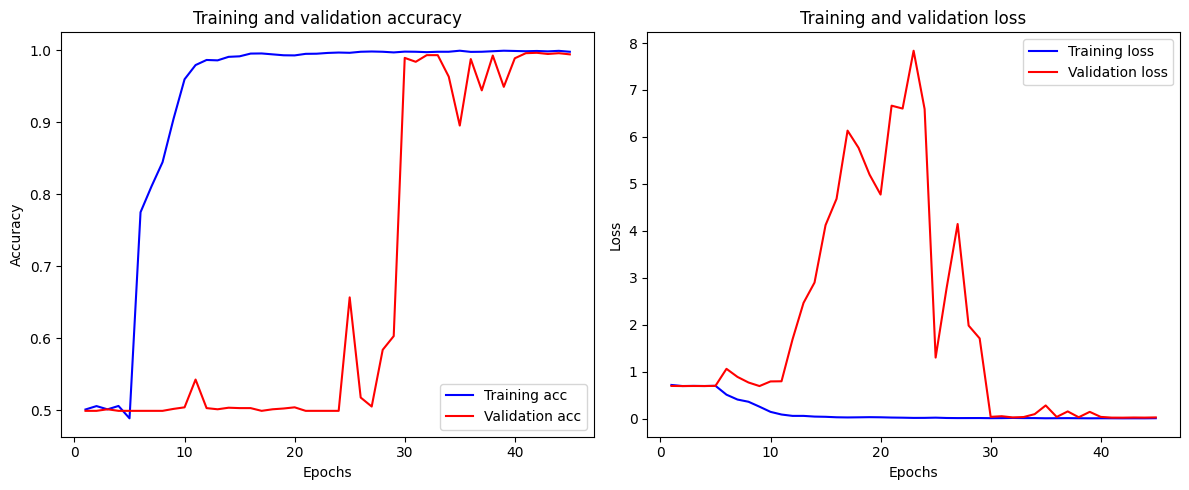

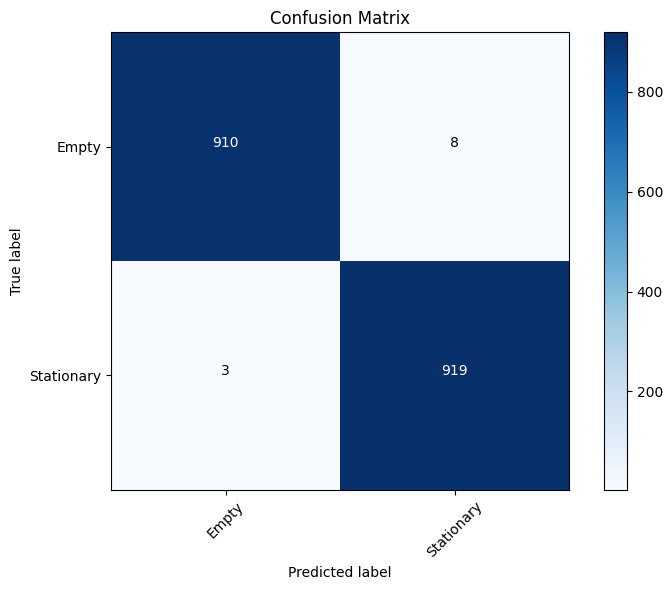

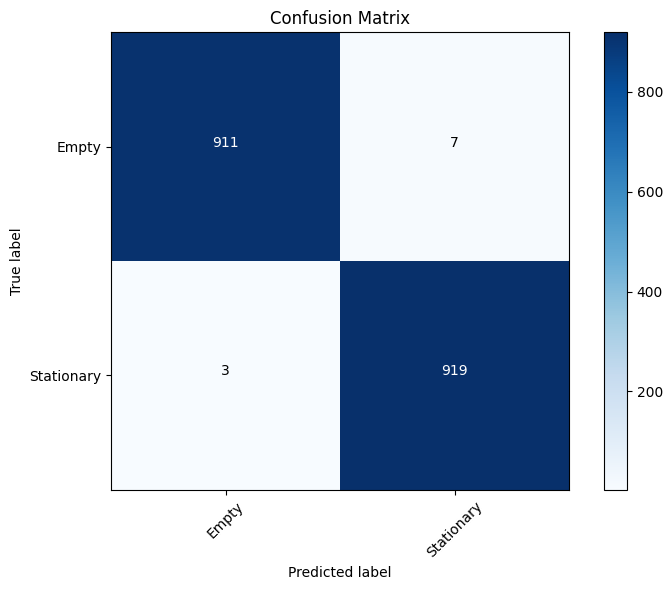

Test Classification Report:
                Empty  Stationary  accuracy    macro avg  weighted avg
precision    0.996718    0.992441  0.994565     0.994579      0.994575
recall       0.992375    0.996746  0.994565     0.994560      0.994565
f1-score     0.994541    0.994589  0.994565     0.994565      0.994565
support    918.000000  922.000000  0.994565  1840.000000   1840.000000


: 

In [ ]:
#plot cm, acc, loss, f1-score, etc.
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_metrics(hist1, hist2):
    acc = hist1.history['acc'] + hist2.history['acc']
    val_acc = hist1.history['val_acc'] + hist2.history['val_acc']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
plot_metrics(hist1, hist2)
#Confuse MatrixPlot
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
cm_val = pd.read_csv(os.path.join(OUT_DIR, "metrics_val_confusion.csv")).values
plot_confusion_matrix(cm_val, CLASSES)
cm_test_path = os.path.join(OUT_DIR, "metrics_test_confusion.csv")
if os.path.exists(cm_test_path):
    cm_test = pd.read_csv(cm_test_path).values
    plot_confusion_matrix(cm_test, CLASSES)

#classification report
def print_classification_report(report_path):
    df = pd.read_csv(report_path, index_col=0)
    print(df)
if os.path.exists(test_report_path):
    print("Test Classification Report:")
    print_classification_report(test_report_path)
#release gpu memory
tf.keras.backend.clear_session()